# Data Loading & EDA

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/archive'   # ← change to your folder

TRAIN_PATH     = f'{DATA_DIR}/train_40k.csv'
VAL_PATH       = f'{DATA_DIR}/val_10k.csv'
UNLABELED_PATH = f'{DATA_DIR}/unlabeled_150k.csv'

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_unlabeled = pd.read_csv(UNLABELED_PATH)

# 2. Melihat ringkasan data
print(f'  train_40k      : {df_train.shape}')
print(f'  val_10k        : {df_val.shape}')
print(f'  unlabeled_150k : {df_unlabeled.shape}')
print(f'\nTrain columns  : {df_train.columns.tolist()}')
print(f'Unlabeled cols : {df_unlabeled.columns.tolist()}')
display(df_train.head())

  train_40k      : (40000, 10)
  val_10k        : (10000, 10)
  unlabeled_150k : (150000, 2)

Train columns  : ['productId', 'Title', 'userId', 'Helpfulness', 'Score', 'Time', 'Text', 'Cat1', 'Cat2', 'Cat3']
Unlabeled cols : ['Title', 'Text']


,productId,Title,userId,Helpfulness,Score,Time,Text,Cat1,Cat2,Cat3
0,B000E46LYG,Golden Valley Natural Buffalo Jerky,A3MQDNGHDJU4MK,0/0,3.0,-1,The description and photo on this product need...,grocery gourmet food,meat poultry,jerky
1,B000GRA6N8,Westing Game,unknown,0/0,5.0,860630400,This was a great book!!!! It is well thought t...,toys games,games,unknown
2,B000GRA6N8,Westing Game,unknown,0/0,5.0,883008000,"I am a first year teacher, teaching 5th grade....",toys games,games,unknown
3,B000GRA6N8,Westing Game,unknown,0/0,5.0,897696000,I got the book at my bookfair at school lookin...,toys games,games,unknown
4,B00000DMDQ,I SPY A is For Jigsaw Puzzle 63pc,unknown,2/4,5.0,911865600,Hi! I'm Martine Redman and I created this puzz...,toys games,puzzles,jigsaw puzzles


In [ ]:
# 3. Mengecek jumlah data yang kosong (Missing Values)
print("\n--- Jumlah Missing Values ---")
print(df_train[['Text', 'Cat1', 'Cat2', 'Cat3']].isnull().sum())

# 4. Melihat persentase unknown per level
print('\n=== unknown% per level ===')
for name, df in [('TRAIN', df_train), ('VAL', df_val)]:
    for col in ['Cat1','Cat2','Cat3']:
        pct = (df[col].str.lower() == 'unknown').mean() * 100
        print(f'  {name} {col}: {pct:.1f}% unknown')

--- 5 Baris Pertama Data Training ---


,Title,Text,Cat1,Cat2,Cat3
0,Golden Valley Natural Buffalo Jerky,The description and photo on this product need...,grocery gourmet food,meat poultry,jerky
1,Westing Game,This was a great book!!!! It is well thought t...,toys games,games,unknown
2,Westing Game,"I am a first year teacher, teaching 5th grade....",toys games,games,unknown
3,Westing Game,I got the book at my bookfair at school lookin...,toys games,games,unknown
4,I SPY A is For Jigsaw Puzzle 63pc,Hi! I'm Martine Redman and I created this puzz...,toys games,puzzles,jigsaw puzzles



--- Jumlah Missing Values ---
Text    0
Cat1    0
Cat2    0
Cat3    0
dtype: int64

=== unknown% per level ===
  TRAIN Cat1: 0.0% unknown
  TRAIN Cat2: 0.0% unknown
  TRAIN Cat3: 5.7% unknown
  VAL Cat1: 0.0% unknown
  VAL Cat2: 0.0% unknown
  VAL Cat3: 4.9% unknown


/tmp/ipykernel_17250/2204623269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Cat1', data=df_train, order=df_train['Cat1'].value_counts().index, palette='viridis')


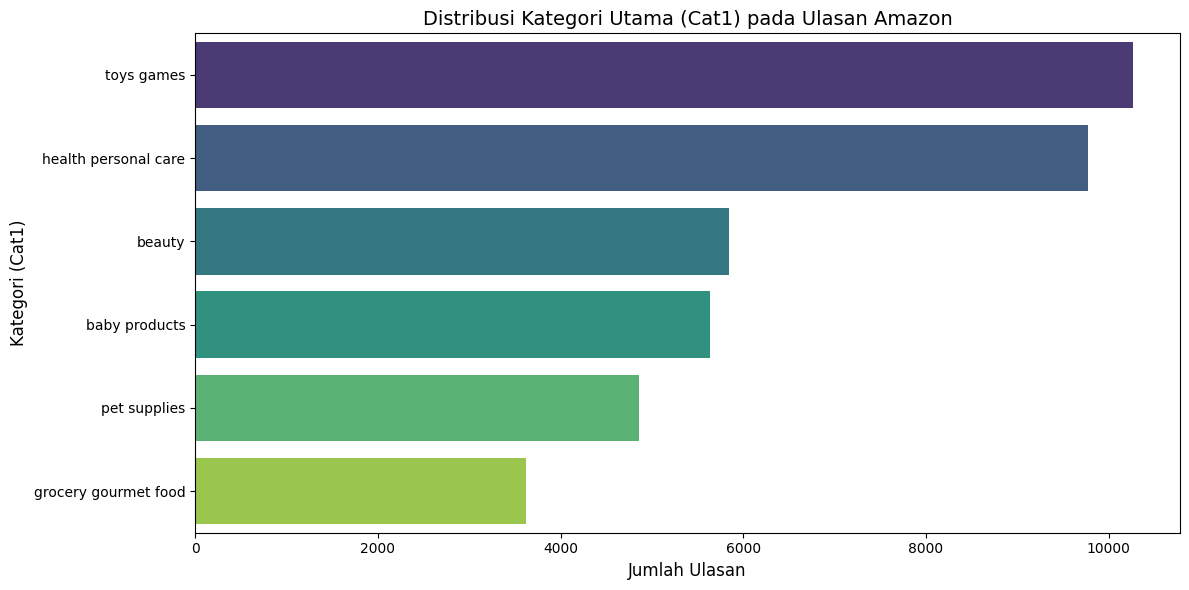

In [ ]:
# 5. Melihat distribusi kategori utama (Cat1) untuk memahami bentuk data
plt.figure(figsize=(12, 6))
sns.countplot(y='Cat1', data=df_train, order=df_train['Cat1'].value_counts().index, palette='viridis')
plt.title('Distribusi Kategori Utama (Cat1) pada Ulasan Amazon', fontsize=14)
plt.xlabel('Jumlah Ulasan', fontsize=12)
plt.ylabel('Kategori (Cat1)', fontsize=12)
plt.tight_layout()
plt.show()

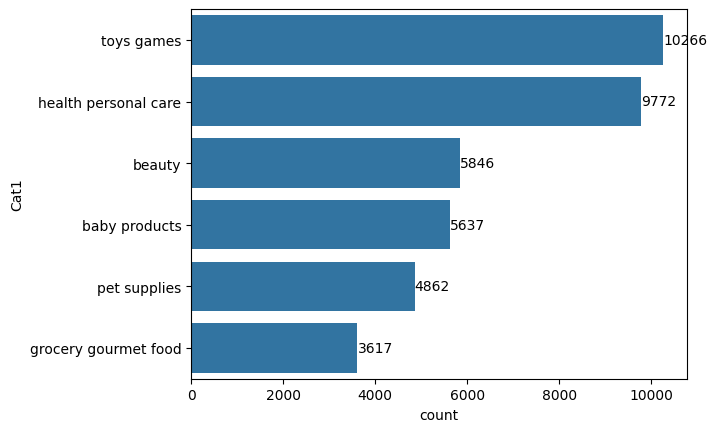

In [3]:
ax = sns.countplot(y='Cat1', data=df_train, order=df_train['Cat1'].value_counts().index)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center')

plt.show()

/tmp/ipykernel_17250/4203594863.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='viridis')
/tmp/ipykernel_17250/4203594863.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='viridis')
/tmp/ipykernel_17250/4203594863.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='viridis')
/tmp/ipykernel_17250/4203594863.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

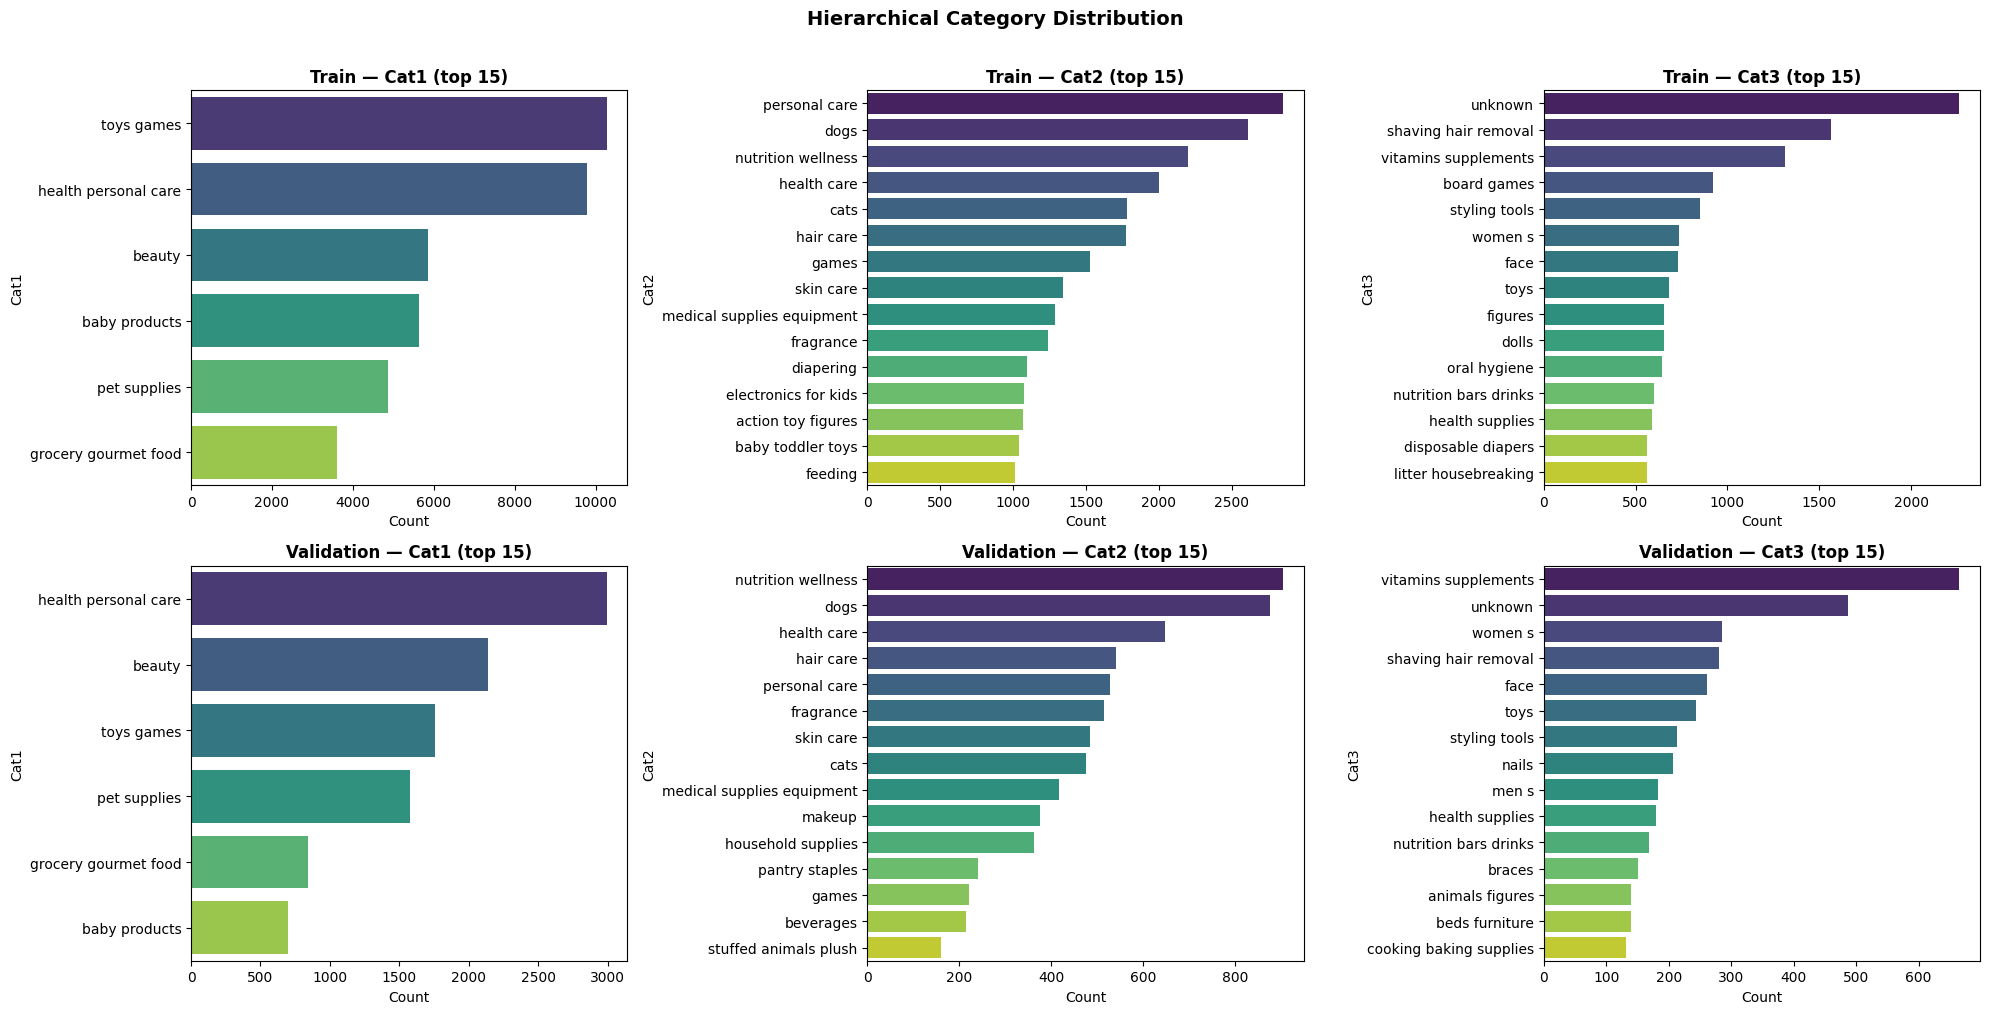

In [ ]:
# Distribusi Kelas Train & Validation
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for row, (name, df) in enumerate([('Train', df_train), ('Validation', df_val)]):
    for col_idx, col in enumerate(['Cat1','Cat2','Cat3']):
        ax = axes[row][col_idx]
        counts = df[col].value_counts().head(15)
        sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='viridis')
        ax.set_title(f'{name} — {col} (top 15)', fontweight='bold')
        ax.set_xlabel('Count')
plt.suptitle('Hierarchical Category Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

Train      | mean=89  median=69  max=1159
Validation | mean=66  median=47  max=1532
Unlabeled  | mean=84  median=63  max=1891


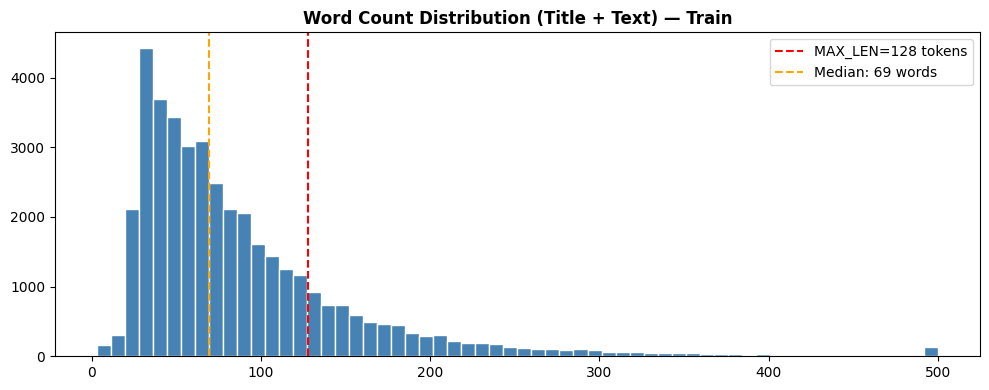

% samples ≤128 words: 81.3%


In [ ]:
# Text Length — Title + Text combined
for name, df in [('Train', df_train), ('Validation', df_val), ('Unlabeled', df_unlabeled)]:
    combined = df['Title'].fillna('') + ' ' + df['Text'].fillna('')
    wc = combined.str.split().str.len()
    print(f'{name:10s} | mean={wc.mean():.0f}  median={wc.median():.0f}  max={wc.max()}')

# Plot distribution for train
combined_train = df_train['Title'].fillna('') + ' ' + df_train['Text'].fillna('')
wc_train = combined_train.str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wc_train.clip(upper=500), bins=60, color='steelblue', edgecolor='white')
ax.axvline(128, color='red', linestyle='--', label='MAX_LEN=128 tokens')
ax.axvline(wc_train.median(), color='orange', linestyle='--', label=f'Median: {wc_train.median():.0f} words')
ax.set_title('Word Count Distribution (Title + Text) — Train', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('text_length_dist.png', bbox_inches='tight')
plt.show()
print(f'% samples ≤128 words: {(wc_train <= 128).mean()*100:.1f}%')

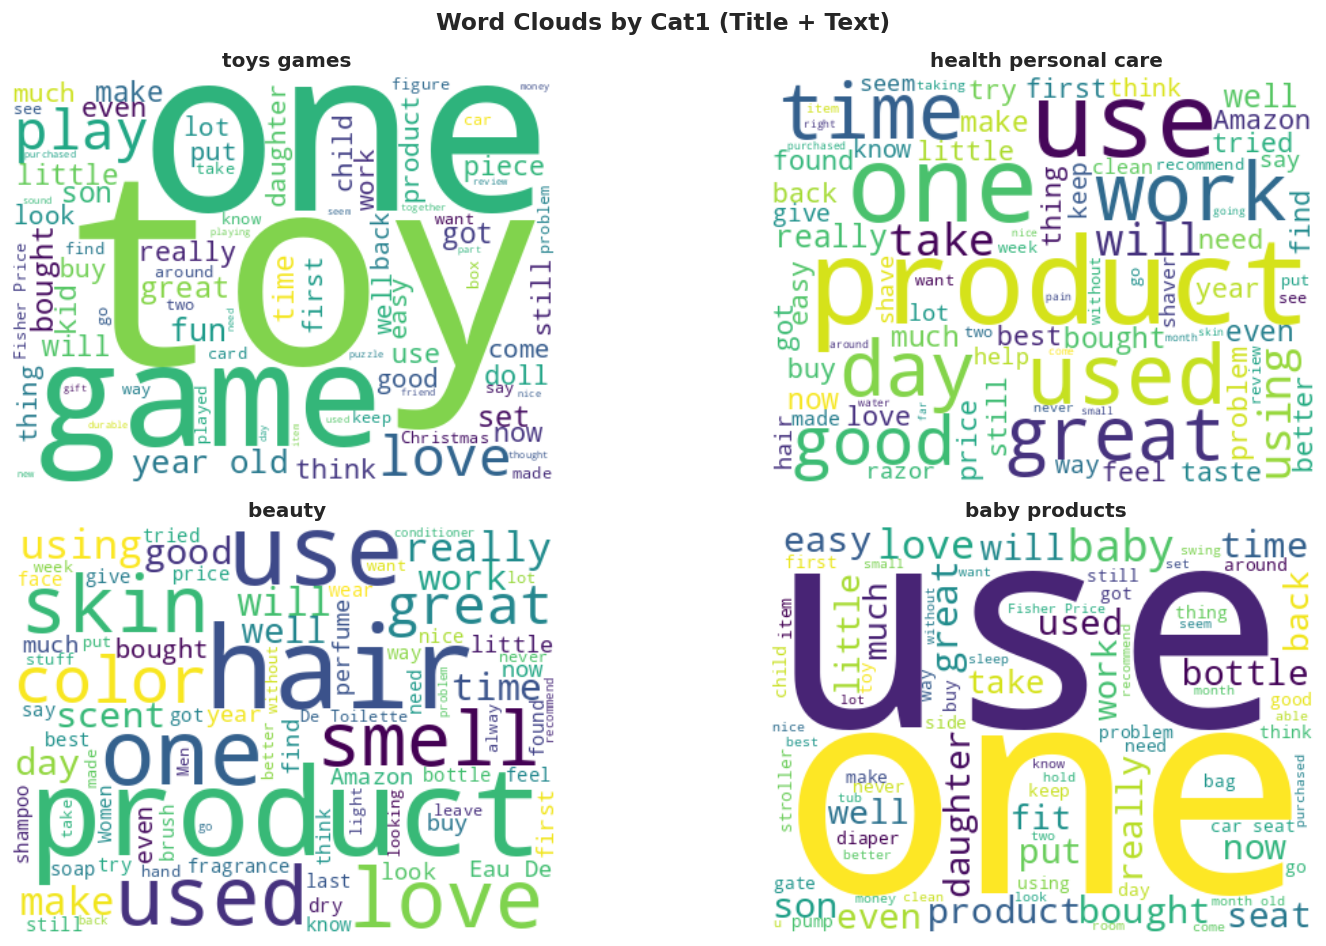

In [ ]:
# Word Cloud per Top Category
top_cats = df_train['Cat1'].value_counts().head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, cat in zip(axes.flatten(), top_cats):
    subset = df_train[df_train['Cat1'] == cat]
    text   = ' '.join((subset['Title'].fillna('') + ' ' + subset['Text'].fillna('')).tolist())
    wc = WordCloud(width=400, height=300, background_color='white', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f' {cat}', fontweight='bold')
    ax.axis('off')
plt.suptitle('Word Clouds by Cat1 (Title + Text)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight')
plt.show()

# Baseline model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Menyiapkan Fitur (X) dan Target (y)
# Kita gunakan kolom 'Text' sebagai input dan 'Cat1' sebagai tebakan
X = df_train['Text']
y = df_train['Cat1']

# 2. Mengubah teks menjadi angka (TF-IDF)
print("Sedang memproses teks... (ini mungkin butuh waktu beberapa detik)")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

# 3. Membagi data menjadi Train (80%) dan Test (20%) dari data 40k
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 4. Melatih Model
print("Sedang melatih model Logistic Regression...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Evaluasi Model
print("\n--- Hasil Akurasi Model ---")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Sedang memproses teks... (ini mungkin butuh waktu beberapa detik)
Sedang melatih model Logistic Regression...

--- Hasil Akurasi Model ---
                      precision    recall  f1-score   support

       baby products       0.86      0.79      0.82      1116
              beauty       0.83      0.79      0.81      1181
grocery gourmet food       0.84      0.73      0.78       709
health personal care       0.72      0.85      0.78      1905
        pet supplies       0.93      0.81      0.87       950
          toys games       0.89      0.90      0.89      2139

            accuracy                           0.83      8000
           macro avg       0.85      0.81      0.83      8000
        weighted avg       0.84      0.83      0.83      8000



In [ ]:
from sklearn.metrics import accuracy_score

# 1. Menyiapkan Fitur (X)
X = df_train['Text']

# Mengubah teks menjadi matriks TF-IDF
print("Memproses TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

# 2. Menyiapkan Target (y) untuk ketiga level
y1 = df_train['Cat1']
y2 = df_train['Cat2']
y3 = df_train['Cat3']

# 3. Membagi data (Train 80%, Test 20%)
# Menggunakan random_state=42 agar urutan barisnya tetap sama dan sinkron
X_train, X_test, y1_train, y1_test = train_test_split(X_tfidf, y1, test_size=0.2, random_state=42)
_, _, y2_train, y2_test = train_test_split(X_tfidf, y2, test_size=0.2, random_state=42)
_, _, y3_train, y3_test = train_test_split(X_tfidf, y3, test_size=0.2, random_state=42)

# 4. Melatih 3 Model Logistik Regresi
print("Melatih Model Cat1...")
model_cat1 = LogisticRegression(max_iter=1000)
model_cat1.fit(X_train, y1_train)

print("Melatih Model Cat2...")
model_cat2 = LogisticRegression(max_iter=1000)
model_cat2.fit(X_train, y2_train)

print("Melatih Model Cat3...")
model_cat3 = LogisticRegression(max_iter=1000)
model_cat3.fit(X_train, y3_train)

# 5. Evaluasi Ketiga Model
print("\n--- Hasil Akurasi Hierarchical Classification ---")
print(f"Akurasi Cat1: {accuracy_score(y1_test, model_cat1.predict(X_test)):.2f}")
print(f"Akurasi Cat2: {accuracy_score(y2_test, model_cat2.predict(X_test)):.2f}")
print(f"Akurasi Cat3: {accuracy_score(y3_test, model_cat3.predict(X_test)):.2f}")

Memproses TF-IDF...
Melatih Model Cat1...
Melatih Model Cat2...
Melatih Model Cat3...

--- Hasil Akurasi Hierarchical Classification ---
Akurasi Cat1: 0.83
Akurasi Cat2: 0.63
Akurasi Cat3: 0.47


## Validasi

In [ ]:
# Membersihkan baris yang mungkin kosong untuk berjaga-jaga
df_val = df_val.dropna(subset=['Text', 'Cat1', 'Cat2', 'Cat3'])

# Menyiapkan Fitur (X) dan Target (y) dari data validasi
X_val_text = df_val['Text']
y1_val = df_val['Cat1']
y2_val = df_val['Cat2']
y3_val = df_val['Cat3']

# Mengubah teks validasi menjadi angka
# PERHATIAN: Di sini kita HANYA menggunakan .transform(), bukan .fit_transform()
print("Memproses TF-IDF untuk data validasi...")
X_val_tfidf = vectorizer.transform(X_val_text)

# Melakukan Prediksi dan Mengukur Akurasi Akhir
print("\n--- Hasil Akurasi Akhir (Dunia Nyata / Val 10k) ---")
print(f"Akurasi Cat1 (Val): {accuracy_score(y1_val, model_cat1.predict(X_val_tfidf)):.2f}")
print(f"Akurasi Cat2 (Val): {accuracy_score(y2_val, model_cat2.predict(X_val_tfidf)):.2f}")
print(f"Akurasi Cat3 (Val): {accuracy_score(y3_val, model_cat3.predict(X_val_tfidf)):.2f}")

Memproses TF-IDF untuk data validasi...

--- Hasil Akurasi Akhir (Dunia Nyata / Val 10k) ---
Akurasi Cat1 (Val): 0.79
Akurasi Cat2 (Val): 0.58
Akurasi Cat3 (Val): 0.43


# Unlabeled

In [ ]:
import numpy as np
import scipy.sparse as sp
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

print("1. Membaca data unlabeled_150k...")
df_unlabeled = df_unlabeled.dropna(subset=['Text'])

print("2. Memproses TF-IDF untuk data unlabeled...")
# WAJIB menggunakan .transform(), BUKAN .fit_transform()
X_unlabeled_tfidf = vectorizer.transform(df_unlabeled['Text'])

print("3. Melakukan tebakan probabilitas (Pseudo-Labeling) pada Cat1...")
# Menggunakan model_cat1 yang sebelumnya sudah dilatih dengan 40k data
probs_cat1 = model_cat1.predict_proba(X_unlabeled_tfidf)

# Mengambil probabilitas tertinggi (tingkat keyakinan) dan kelas tebakannya
max_probs_cat1 = np.max(probs_cat1, axis=1)
predicted_classes_cat1 = model_cat1.classes_[np.argmax(probs_cat1, axis=1)]

# 4. Filter Threshold Keyakinan
threshold = 0.90 # Hanya ambil data yang model yakin > 90%
confident_indices = np.where(max_probs_cat1 > threshold)[0]
print(f"Dari 150k data, terdapat {len(confident_indices)} data dengan keyakinan > 90%.")

# Mengambil data teks dan label hasil tebakan yang lulus filter
X_pseudo = X_unlabeled_tfidf[confident_indices]
y_pseudo = predicted_classes_cat1[confident_indices]

print("5. Menggabungkan data baru dengan data training asli (40k)...")
# X_train_tfidf dan y1_train berasal dari blok kode Anda sebelumnya
X_train_combined = sp.vstack([X_train, X_pseudo])
y_train_combined = pd.concat([y1_train, pd.Series(y_pseudo)])

print(f"Total data training sekarang: {X_train_combined.shape[0]} baris.")

print("6. Melatih ulang model Cat1 dengan data gabungan...")
model_cat1_pseudo = LogisticRegression(max_iter=1000)
model_cat1_pseudo.fit(X_train_combined, y_train_combined)

print("\n--- Evaluasi Model Baru (Diuji pada val_10k) ---")
akurasi_lama = accuracy_score(y1_val, model_cat1.predict(X_val_tfidf))
akurasi_baru = accuracy_score(y1_val, model_cat1_pseudo.predict(X_val_tfidf))

print(f"Akurasi Cat1 Lama: {akurasi_lama:.4f}")
print(f"Akurasi Cat1 Baru (Pseudo-Labeling): {akurasi_baru:.4f}")

1. Membaca data unlabeled_150k...
2. Memproses TF-IDF untuk data unlabeled...
3. Melakukan tebakan probabilitas (Pseudo-Labeling) pada Cat1...
Dari 150k data, terdapat 47686 data dengan keyakinan > 90%.
5. Menggabungkan data baru dengan data training asli (40k)...
Total data training sekarang: 79686 baris.
6. Melatih ulang model Cat1 dengan data gabungan...

--- Evaluasi Model Baru (Diuji pada val_10k) ---
Akurasi Cat1 Lama: 0.7867
Akurasi Cat1 Baru (Pseudo-Labeling): 0.7867


In [ ]:
print("--- Pseudo-Labeling untuk Cat 2 ---")
# 1. Tebak probabilitas dan kelas Cat2
probs_cat2 = model_cat2.predict_proba(X_unlabeled_tfidf)
max_probs_cat2 = np.max(probs_cat2, axis=1)
predicted_classes_cat2 = model_cat2.classes_[np.argmax(probs_cat2, axis=1)]

# 2. Filter keyakinan > 90%
confident_indices_cat2 = np.where(max_probs_cat2 > threshold)[0]
print(f"Cat2: Ada {len(confident_indices_cat2)} data dengan keyakinan > 90%.")

# 3. Gabungkan dan latih ulang Cat2
X_pseudo_cat2 = X_unlabeled_tfidf[confident_indices_cat2]
y_pseudo_cat2 = predicted_classes_cat2[confident_indices_cat2]
X_train_combined_cat2 = sp.vstack([X_train, X_pseudo_cat2])
y_train_combined_cat2 = pd.concat([y2_train, pd.Series(y_pseudo_cat2)])

print("Melatih ulang model Cat2...")
model_cat2_pseudo = LogisticRegression(max_iter=1000)
model_cat2_pseudo.fit(X_train_combined_cat2, y_train_combined_cat2)

print("\n--- Evaluasi Akhir Model Baru (Diuji pada val_10k) ---")
print(f"Akurasi Cat2 Lama: {accuracy_score(y2_val, model_cat2.predict(X_val_tfidf)):.4f}")
print(f"Akurasi Cat2 Baru: {accuracy_score(y2_val, model_cat2_pseudo.predict(X_val_tfidf)):.4f}")

--- Pseudo-Labeling untuk Cat 2 ---
Cat2: Ada 17029 data dengan keyakinan > 90%.
Melatih ulang model Cat2...

--- Evaluasi Akhir Model Baru (Diuji pada val_10k) ---
Akurasi Cat2 Lama: 0.5768
Akurasi Cat2 Baru: 0.5793


In [ ]:
print("\n--- Pseudo-Labeling untuk Cat 3 ---")
# 1. Tebak probabilitas dan kelas Cat3
probs_cat3 = model_cat3.predict_proba(X_unlabeled_tfidf)
max_probs_cat3 = np.max(probs_cat3, axis=1)
predicted_classes_cat3 = model_cat3.classes_[np.argmax(probs_cat3, axis=1)]

# 2. Filter keyakinan > 90%
confident_indices_cat3 = np.where(max_probs_cat3 > threshold)[0]
print(f"Cat3: Ada {len(confident_indices_cat3)} data dengan keyakinan > 90%.")

# 3. Gabungkan dan latih ulang Cat3
X_pseudo_cat3 = X_unlabeled_tfidf[confident_indices_cat3]
y_pseudo_cat3 = predicted_classes_cat3[confident_indices_cat3]
X_train_combined_cat3 = sp.vstack([X_train, X_pseudo_cat3])
y_train_combined_cat3 = pd.concat([y3_train, pd.Series(y_pseudo_cat3)])

print("Melatih ulang model Cat3...")
model_cat3_pseudo = LogisticRegression(max_iter=1000)
model_cat3_pseudo.fit(X_train_combined_cat3, y_train_combined_cat3)

print("\n--- Evaluasi Akhir Model Baru (Diuji pada val_10k) ---")
print(f"Akurasi Cat3 Lama: {accuracy_score(y3_val, model_cat3.predict(X_val_tfidf)):.4f}")
print(f"Akurasi Cat3 Baru: {accuracy_score(y3_val, model_cat3_pseudo.predict(X_val_tfidf)):.4f}")


--- Pseudo-Labeling untuk Cat 3 ---
Cat3: Ada 7132 data dengan keyakinan > 90%.
Melatih ulang model Cat3...

--- Evaluasi Akhir Model Baru (Diuji pada val_10k) ---
Akurasi Cat3 Lama: 0.4277
Akurasi Cat3 Baru: 0.4273


# Persiapan API

In [ ]:
import joblib

# Menyimpan ekstraktor fitur (TF-IDF)
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Menyimpan ketiga model Logistic Regression
joblib.dump(model_cat1, 'model_cat1.pkl')
joblib.dump(model_cat2, 'model_cat2.pkl')
joblib.dump(model_cat3, 'model_cat3.pkl')

print("Semua model berhasil disimpan! Silakan cek folder di panel sebelah kiri.")

Semua model berhasil disimpan! Silakan cek folder di panel sebelah kiri.
